In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from daemon_analysis_tools.io.csv_handler import load_and_process_csv
from daemon_analysis_tools.io.yaml_handler import save_answers_to_yaml, load_answers_from_yaml

Load and process data:
- Group answers by publisher and journal, trying to uniform names written in slightly different ways.
- Store in a DataFrame

In [3]:
grouped_questions = load_answers_from_yaml('../../data/processed/all_answers')

rdp_exist {'text': '1. Existence of research data policy', 'N. encoders': 1, 'has_discrepancies': False, 0: {'text': 'Research Data Policy (RDP) exists.', 'explanation': 'Text from Journal Research Data Policy : \n" All ACS journals strongly encourage authors to make the research data underlying their articles publicly available at the time of publication. "\n\nText from Publishers ACS Research Data Policy :\n" Where ethically and legally feasible, all ACS journals strongly encourage authors to make the research data underlying their articles publicly available at the time of publication. "'}, 'correct_answer': None, 'discrepancy_reason': None}
No discrepancies detected.
data_sharing {'text': '3. Data sharing requirements in RDP', 'N. encoders': 1, 'has_discrepancies': False, 0: {'text': 'Data sharing encouraged but optional.', 'explanation': 'Text from Journal Research Data Policy : \n" All ACS journals strongly encourage authors to make the research data underlying their articles pub

In [4]:
for publisher, journals in grouped_questions.items():
    for journal, data in journals.items():
        for question, answer in data.items():
            if answer.has_discrepancies():
                print(publisher, journal, question, answer.discrepancy_reason)

Get a `dict` labeled by publisher names of `dict`s labeled by journal names of `dict`s of `Question` instances. The `.answer` attribute contains the answers given by the respondents and the explanations text to motivate it.

ACS 16
AIP 14
APS 11
Bentham Science 6
Elsevier 10
Frontiers 7
IEEE 15
IOP 9
MDPI 15
Optica 9
Pleiades Publishing 9
RSC 9
Springer Nature 10
Taylor & Francis 15
Wiley 15


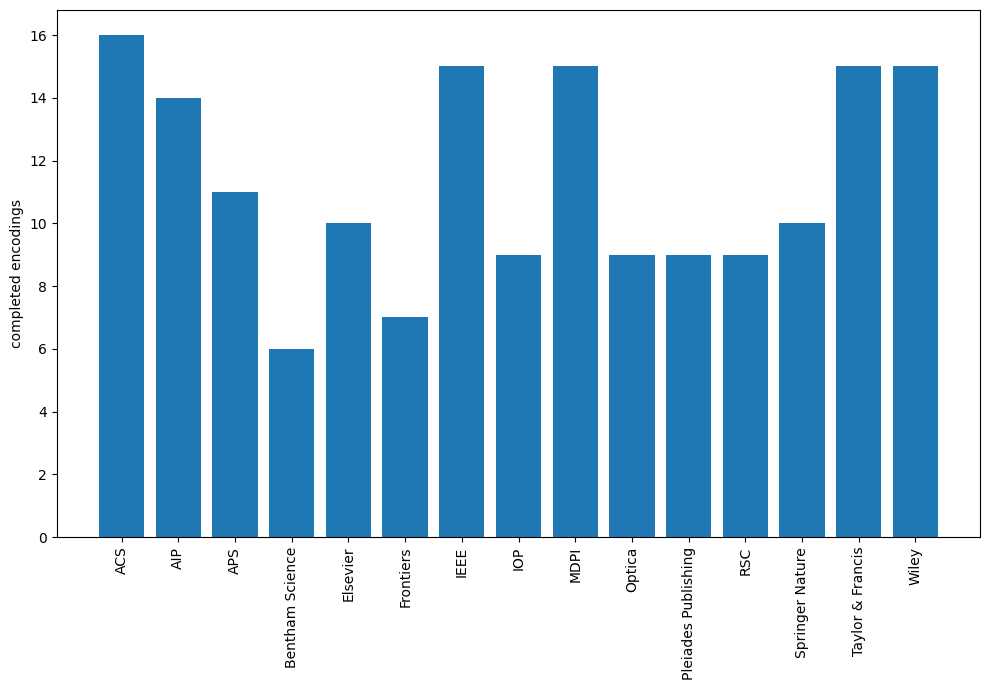

In [5]:
import matplotlib.pyplot as plt

n_journals = {}

x = []
y = []

for publisher, journals in grouped_questions.items():
    n_journals[publisher] = len(journals)

for publisher, num in n_journals.items():
    x.append(publisher)
    y.append(num)
    print(publisher, num)

x_0 = list(range(len(x)))

# Creating plot
fig = plt.figure(figsize=(10, 7))
plt.bar(x_0, y)
plt.xticks(x_0, x, rotation=90)
plt.ylabel("completed encodings")
plt.tight_layout()

fig.savefig("../../data/processed/number_of_encodings.pdf")